In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

In [24]:
# ------------------ Load and Prepare Data ------------------
df = pd.read_csv("youth_data.csv")

# Drop invalid/missing SMKLSMDAYS and keep values within valid range (0–30)
df = df[df['SMKLSMDAYS'].between(0, 30)].copy()

In [25]:
# ------------------ Feature Engineering ------------------
# Combine school and parental help into one feature (captures home-school interaction)
df['SCHOOL_FAMILY'] = df['PARHLPHW'] * df['SCHFELT']

# Combine peer influence variables into a single composite metric
df['PEER_INFLUENCE'] = df['FRDMEVR2'] * df['FRDMJMON']

# ------------------ Define Features and Target ------------------

# Select relevant features
X = df[['PARHLPHW', 'SCHFELT', 'INCOME', 'SCHOOL_FAMILY',
        'PEER_INFLUENCE', 'YOGRPFT2', 'HEALTH2']]

# Target variable: number of days smokeless tobacco was used (categorical classification)
y = df['SMKLSMDAYS']

# Match indices (just in case)
X = X.loc[df.index]
y = y.loc[df.index]

In [26]:
# ------------------ Handle Missing Values ------------------
# Impute missing numeric values using mean to avoid dropping rows
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ------------------ Train-Test Split ------------------

# Split into 80% train and 20% test; stratify to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=50
)

# ------------------ Initialize Classifier ------------------

# Decision Tree Classifier for multi-class classification
clf = DecisionTreeClassifier(
    max_depth=5,             # Limit tree complexity to prevent overfitting
    min_samples_leaf=10,     # Each leaf must have at least 10 samples
    class_weight='balanced', # Compensate for potential class imbalance
    random_state=50
)

In [27]:
# ------------------ Cross-Validation ------------------
# Evaluate generalization with 5-fold cross-validation on training set
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

print("\n🔁 Cross-Validation Results (5-fold):")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: ±{cv_scores.std():.4f}")


🔁 Cross-Validation Results (5-fold):
Mean Accuracy: 0.5710
Standard Deviation: ±0.1282


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [28]:
# ------------------ Train on Full Training Set ------------------
clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, random_state=50)

In [29]:
# ------------------ Prediction and Evaluation ------------------

y_pred = clf.predict(X_test)

print("\n🧾 Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


🧾 Classification Report:
              precision    recall  f1-score   support

           1       0.01      0.50      0.01         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       1.00      0.53      0.70      2107

    accuracy                           0.53      2113
   macro avg       0.20      0.21      0.14      2113
weighted avg       1.00      0.53      0.69      2113

Accuracy: 0.5329


<Figure size 1000x800 with 0 Axes>

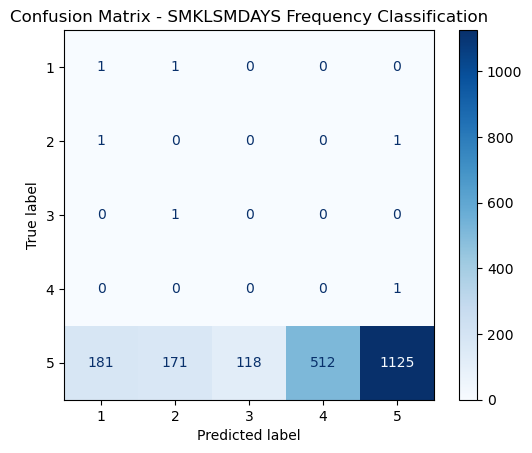

In [38]:
# ------------------ Confusion Matrix ------------------
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix - SMKLSMDAYS Frequency Classification")
plt.grid(False)
plt.show()

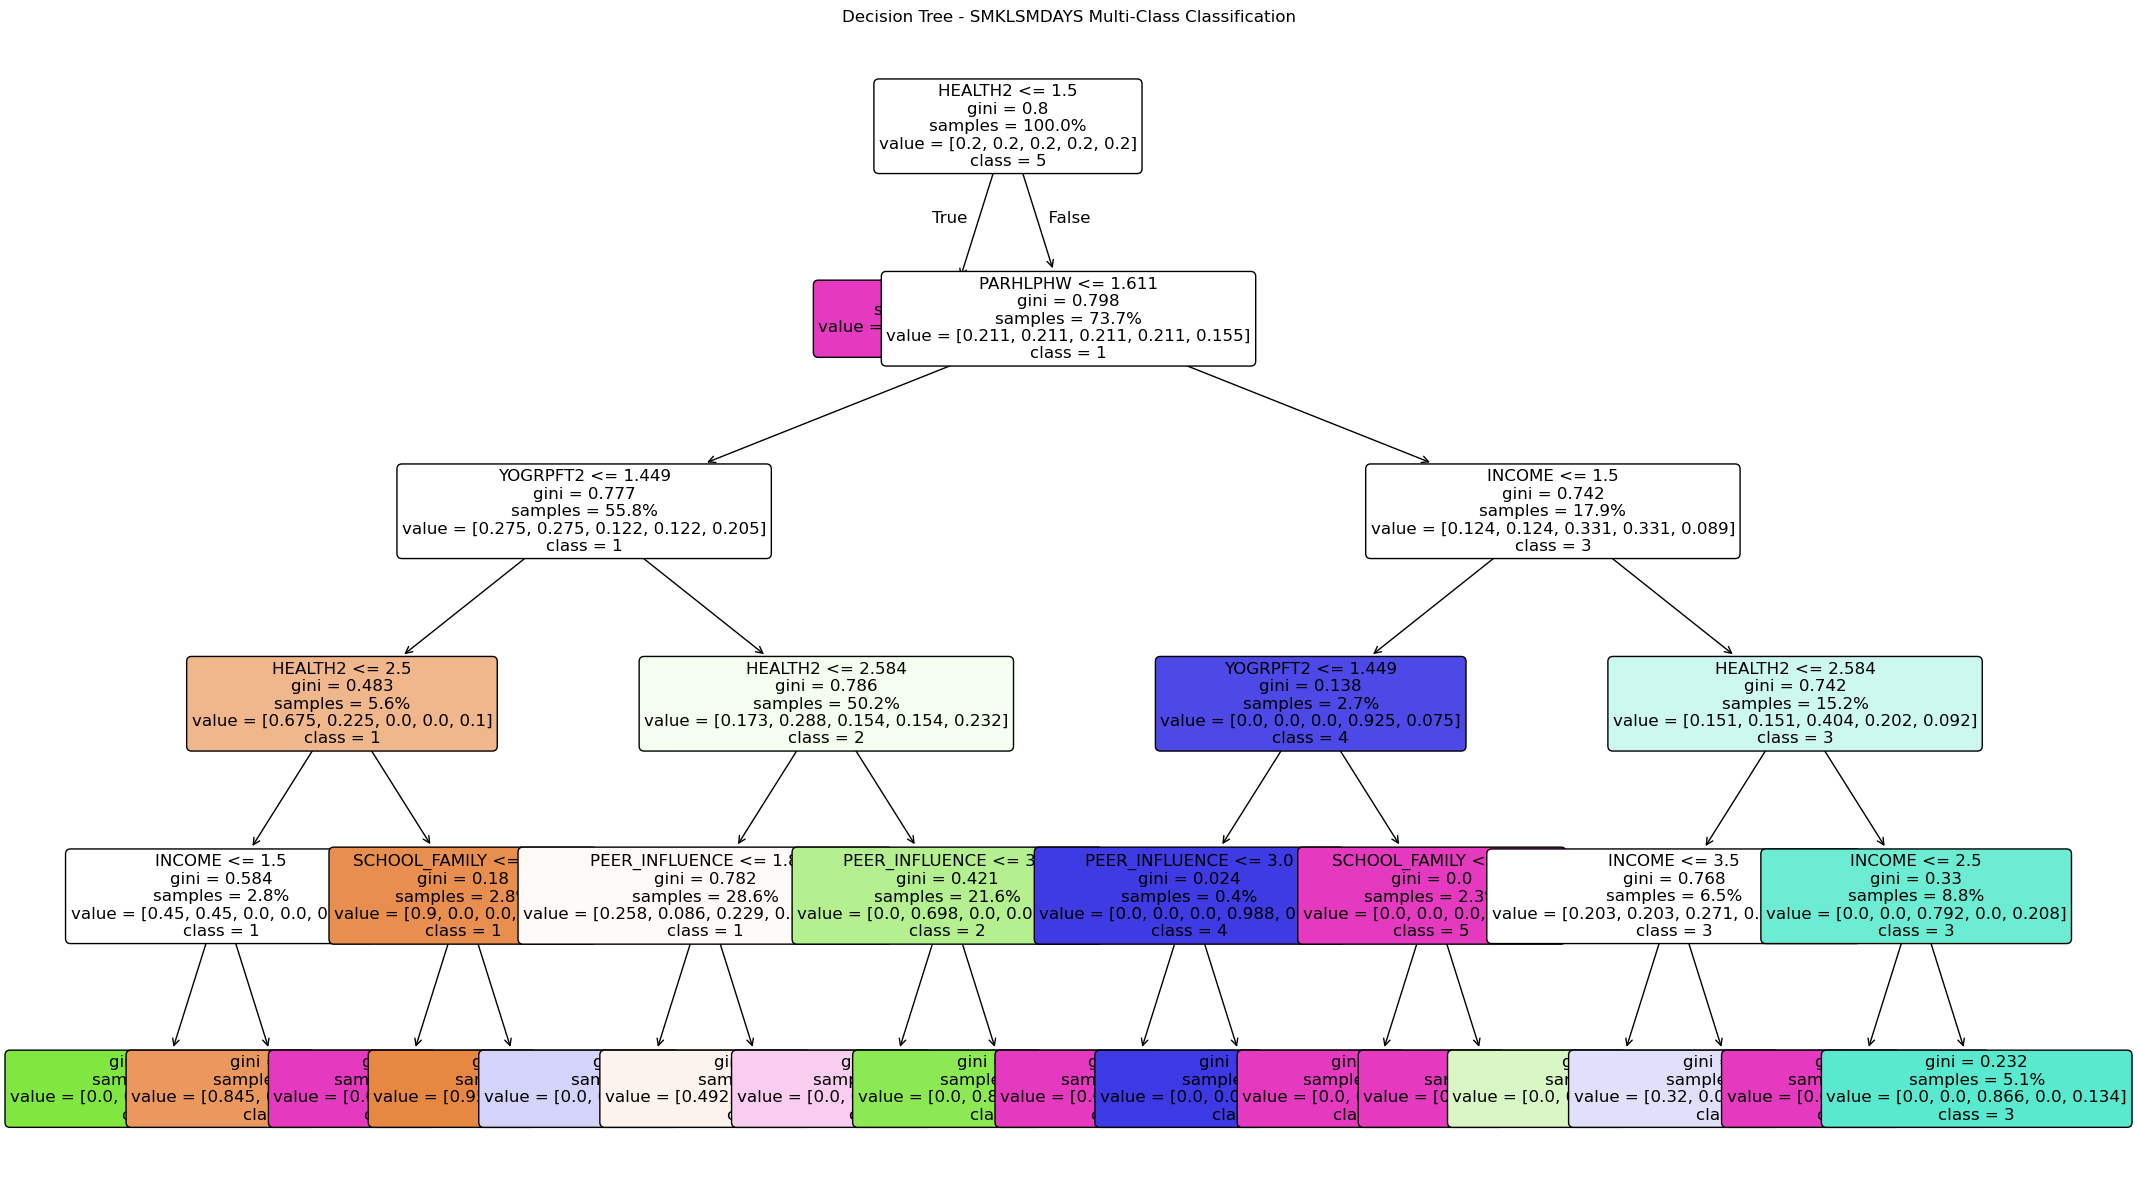


🌳 Tree Structure Info:
Total Nodes: 33
Total Leaves: 17
Max Depth: 5


In [40]:
# ------------------ Visualize the Decision Tree ------------------

plt.figure(figsize=(25, 15))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=[str(cls) for cls in clf.classes_],  # convert numeric classes to string labels
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=12
)
plt.title("Decision Tree - SMKLSMDAYS Multi-Class Classification")
plt.show()

# ------------------ Tree Structure Information ------------------

print("\n🌳 Tree Structure Info:")
print(f"Total Nodes: {clf.tree_.node_count}")
print(f"Total Leaves: {clf.get_n_leaves()}")
print(f"Max Depth: {clf.get_depth()}")


📊 Feature Importance:
          Feature  Importance
6         HEALTH2    0.346894
2          INCOME    0.281200
4  PEER_INFLUENCE    0.179713
5        YOGRPFT2    0.092662
0        PARHLPHW    0.085423
3   SCHOOL_FAMILY    0.014108
1         SCHFELT    0.000000


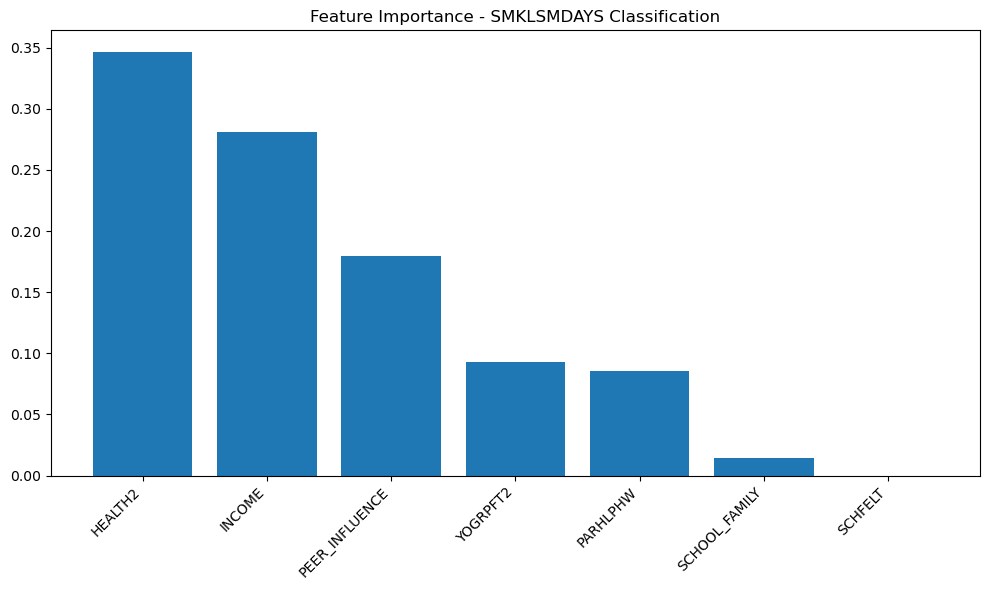

In [42]:
# ------------------ Feature Importance ------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance:")
print(importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title("Feature Importance - SMKLSMDAYS Classification")
plt.tight_layout()
plt.show()

In [44]:
# In conclusion, kids were successfully categorized using the multi-class classification model according to their frequency of usage of smokeless tobacco.  Key differentiators included peer influence, economic level, and health status.  However, the majority of predictions tended to cluster toward higher frequency, most likely as a result of the dataset's skewed distribution.  The decision tree approach nevertheless defined behavioral segmentation based on socioeconomic and health factors and assisted in interpreting different usage patterns.